# 01 · Exploratory data analysis

The dataset analysis of #17, read from the committed `eda/summary.json` alone: no images,
weights or raw data are needed to run this notebook. `uv run ryuk eda` writes the summary from
the fetched data; section 2 of the report (`report/`) is the written account of the same
numbers and figures.

In [1]:
from pathlib import Path

from matplotlib_inline.backend_inline import set_matplotlib_formats

from ryuk.eda.files import read_summary
from ryuk.plotting import EDA_FIGURES, caption, use_lab_style

use_lab_style()
# PNG at the style's 150 dpi keeps the committed notebook small; the figures are drawn with
# constrained layout, so the inline backend's tight bounding box would only pad them.
set_matplotlib_formats("png", bbox_inches=None)

# The notebook runs in notebooks/, so the committed summary is one level up.
summary = read_summary(Path("../eda"))
provenance = summary.provenance
print(f"Summary of {provenance.generated}, commit {provenance.git_commit[:7]}")
print(
    f"YuNet score threshold {provenance.score_threshold:g}, "
    f"NMS threshold {provenance.nms_threshold:g}"
)

Summary of 2026-09-25, commit 13e912a
YuNet score threshold 0.9, NMS threshold 0.3


## LFW

LFW is used only through its published pairs lists, for verification. Its identities are spread
very unevenly: most have a single image, so only a minority can appear in a matched pair.

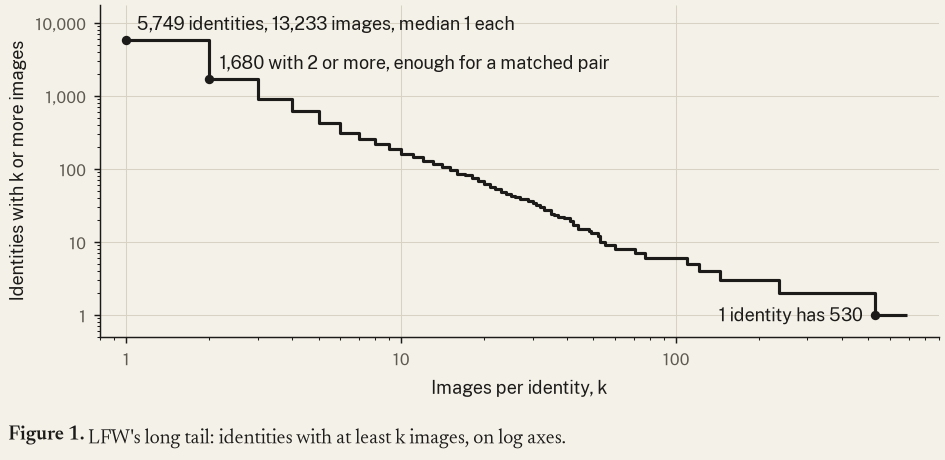

In [2]:
fig = EDA_FIGURES["lfw-images-per-identity"](summary)
caption(
    fig,
    1,
    "LFW's long tail: identities with at least k images, on log axes.",
)
fig

View 1's two lists tune pipeline choices; View 2's ten folds give the reported accuracy. The last
column counts pairs with an image that has no usable face, which #26 has to score somehow, since
published LFW accuracies are over every pair.

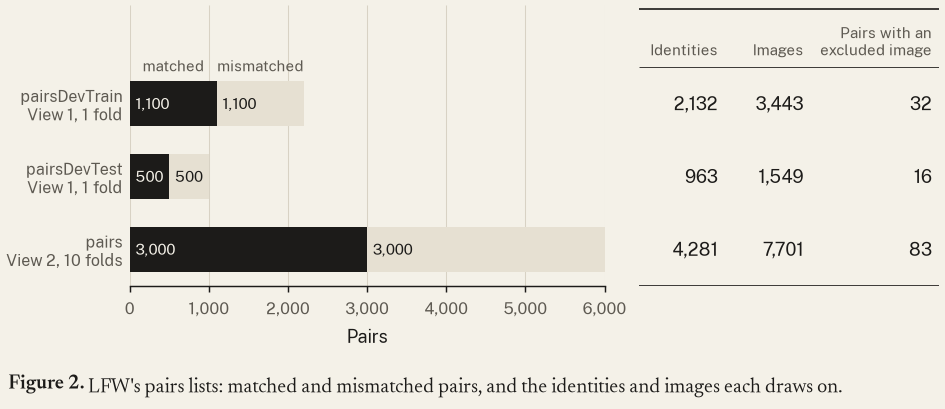

In [3]:
fig = EDA_FIGURES["lfw-pair-composition"](summary)
caption(
    fig,
    2,
    "LFW's pairs lists: matched and mismatched pairs, and the identities and images each draws on.",
)
fig

## CelebA draws

The validation draw is CelebA's `valid` split and the test draw its `test` split; they share no
identities. #9's gallery rule needs at least 20 images per identity, marked on the figure.

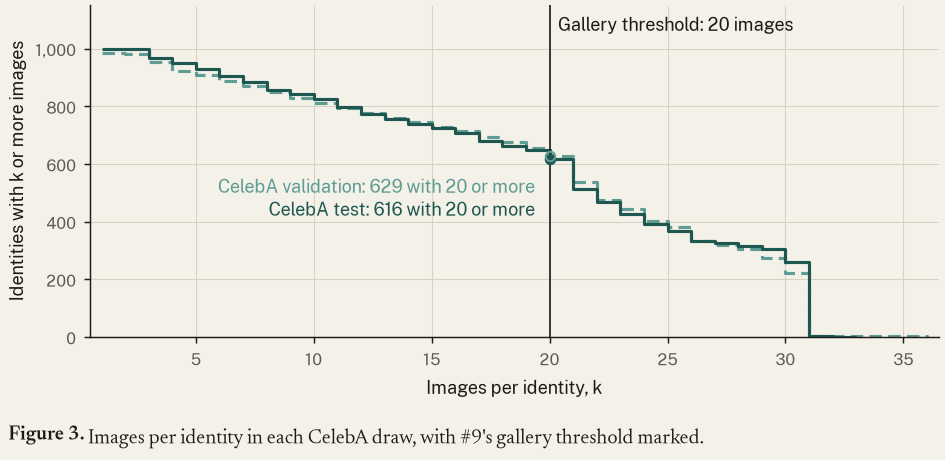

In [4]:
fig = EDA_FIGURES["celeba-images-per-identity"](summary)
caption(
    fig,
    3,
    "Images per identity in each CelebA draw, with #9's gallery threshold marked.",
)
fig

Male and Young describe the person, and #10 gives an identity one of their groups only when at
least 80% of its images agree; the rest are mixed and get no group. Eyeglasses, Wearing_Hat and
Blurry describe the photo and vary between one identity's images, so they group images instead.

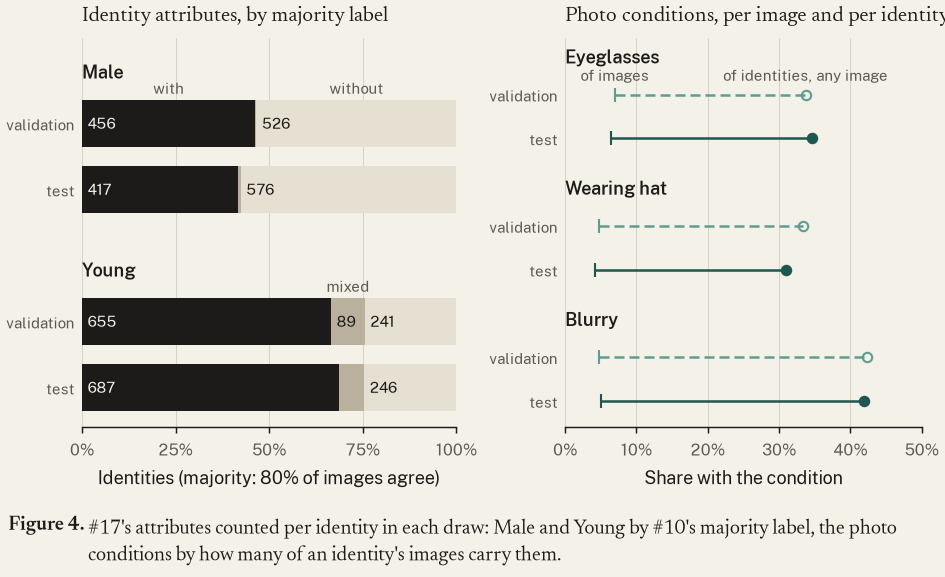

In [5]:
fig = EDA_FIGURES["celeba-attribute-prevalence"](summary)
caption(
    fig,
    4,
    "#17's attributes counted per identity in each draw: Male and Young by #10's majority "
    "label, the photo conditions by how many of an identity's images carry them.",
)
fig

## Detection and the minimum usable face size

YuNet re-detects a face in almost every LFW image and in most CelebA images, but not evenly: it
misses more of the majority-male and not-young identities' photos, and more again of blurred,
hatted and bespectacled ones. A detector that fails more on some groups skews the bias
breakdown before any recognition model runs.

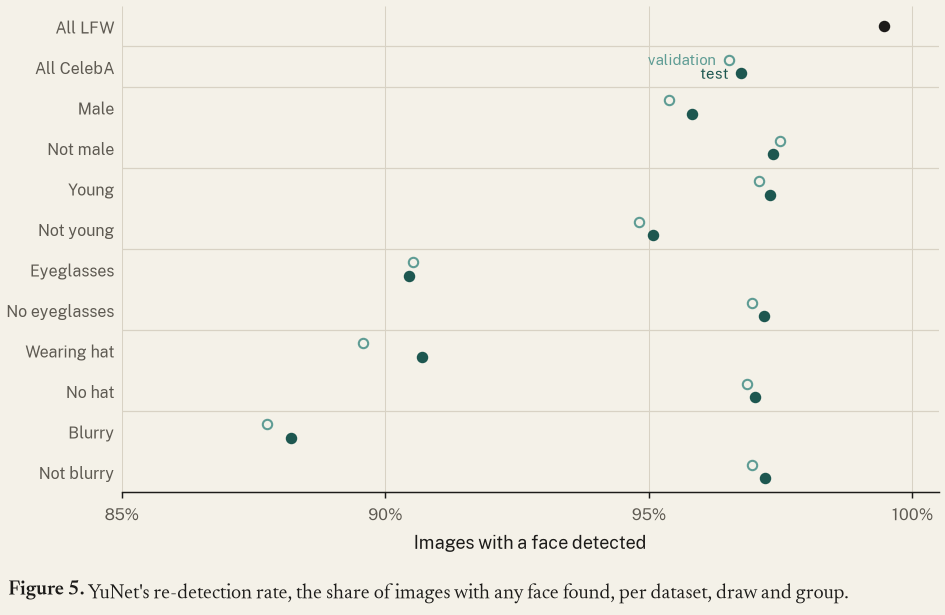

In [6]:
fig = EDA_FIGURES["yunet-detection-rate"](summary)
caption(
    fig,
    5,
    "YuNet's re-detection rate, the share of images with any face found, per dataset, draw "
    "and group.",
)
fig

#17's rule sets the minimum usable face size: the largest round pixel value, on the box's short
side, that keeps at least 99% of CelebA's detections. The same value governs enrollment and the
live monitor.

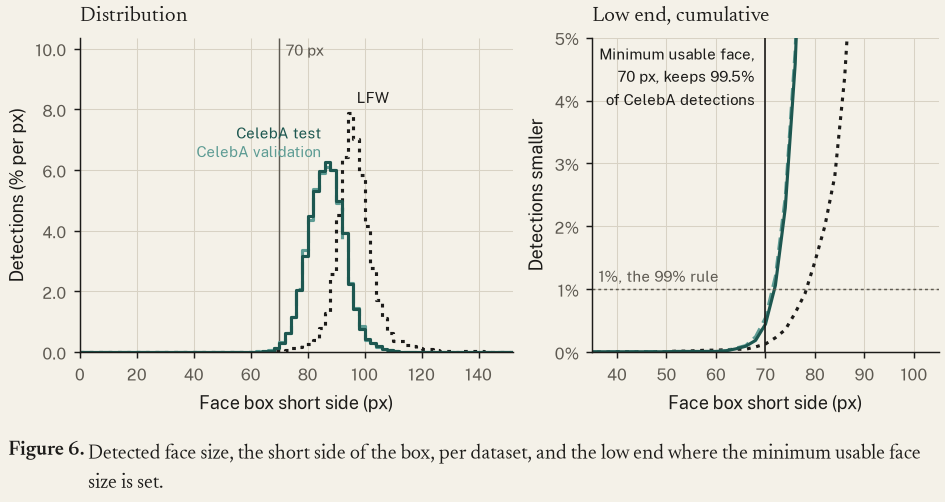

In [7]:
fig = EDA_FIGURES["face-size"](summary)
caption(
    fig,
    6,
    "Detected face size, the short side of the box, per dataset, and the low end where the "
    "minimum usable face size is set.",
)
fig

In [8]:
size = summary.min_usable_face_size
print(
    f"Minimum usable face size: {size.value} px, keeping {size.kept:.1%} of "
    f"{size.detections:,} CelebA detections; {size.value + size.step} px would keep "
    f"{size.kept_at_next_step:.1%}."
)

Minimum usable face size: 70 px, keeping 99.5% of 38,489 CelebA detections; 80 px would keep 84.7%.


The head pose is rough: a generic face fitted to YuNet's five landmarks. YuNet pulls landmarks
towards upright on rotated faces, so the angles are biased towards zero, roll most of all, and
zero pitch means the typical portrait rather than a measured level head. Only the spreads and
the differences between datasets carry information.

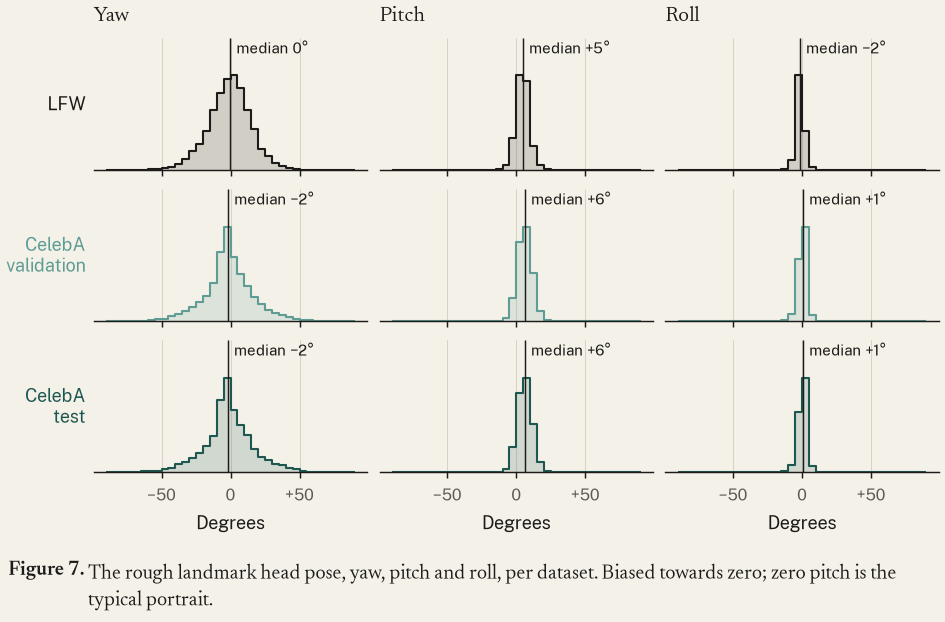

In [9]:
fig = EDA_FIGURES["head-pose"](summary)
caption(
    fig,
    7,
    "The rough landmark head pose, yaw, pitch and roll, per dataset. Biased towards zero; "
    "zero pitch is the typical portrait.",
)
fig

## Exclusions and eligibility

An image with no usable face is excluded, and #9's 20-image rule is then applied to the usable
images. The eligible identities are the pool #27's galleries are drawn from, and their split by
group bounds #10's bias breakdown.

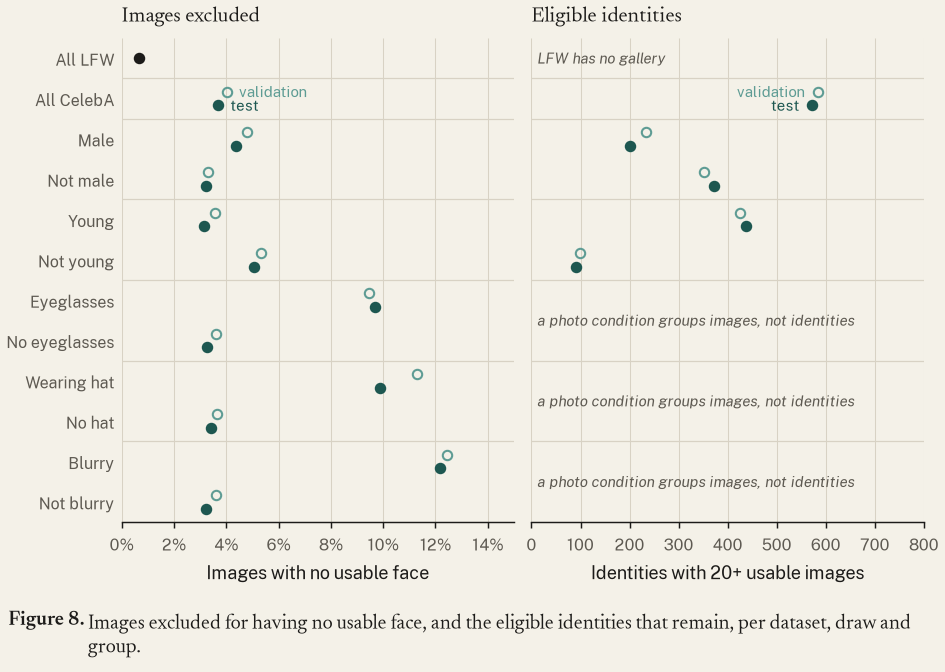

In [10]:
fig = EDA_FIGURES["exclusions"](summary)
caption(
    fig,
    8,
    "Images excluded for having no usable face, and the eligible identities that remain, per "
    "dataset, draw and group.",
)
fig

In [11]:
for draw in summary.celeba:
    print(
        f"{draw.draw}: {draw.gallery_candidates} gallery candidates, "
        f"{draw.eligible_identities} eligible after exclusion"
    )

validation: 629 gallery candidates, 584 eligible after exclusion
test: 616 gallery candidates, 572 eligible after exclusion
